# F9 · Visión clásica: la hipótesis nula del trabajo

**Qué pregunta responde.** Si un método clásico llega lo bastante cerca, embeber SAM no
está justificado: un plugin de Fiji con umbral y morfología se escribe en Java
directamente, sin SAMJ, sin Appose y sin Python.

Tres métodos alimentados por los mismos cinco clics: umbral local tipo Otsu, watershed con
marcadores y filtro de cresta de Sato. Las dos elecciones que el apartado 5.4 dejaba
abiertas se cerraron por no meter parámetros calibrables, y **de los dos números (ventana de
128 px y sigmas de 2 a 11) ninguno se calibró contra los resultados, pero tampoco sale
medido del GT**: la ventana es del orden de la longitud del surco *estimada* en el
apartado 3, y el rango de escalas **se eligió**, acotado para que el filtro no responda ni al
ruido ni al núcleo. Lo que sí está medido es el **paso 4**, y lo mide el barrido de la celda
de más abajo.

**Qué hay que haber corrido antes**, todo en `surco` porque **no depende de ningún entorno
de modelo**:

```
conda run -n surco python scripts/correr_clasicos.py
conda run -n surco python scripts/robustez_sigma.py
conda run -n surco python scripts/clasicos_contra_sam.py
```

La última necesita además los CSV de F8. Este notebook corre en **`surco`**.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

RAIZ = Path.cwd().parent
sys.path.insert(0, str(RAIZ / "scripts"))  # los scripts agregan; el notebook solo muestra

from surco import config, figuras, metricas
pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 50)

from surco import figuras

clasicos = pd.read_csv(config.DIR_PROCESO / "clasicos.csv")        # <- correr_clasicos.py
resumen = pd.read_csv(config.DIR_PROCESO / "tabla_clasicos.csv")   # <- correr_clasicos.py
sigma = pd.read_csv(config.DIR_PROCESO / "robustez_sigma.csv")     # <- robustez_sigma.py
# Los tres se generan en el entorno `surco`: F9 no depende de ningun modelo.

# La comparacion contra SAM no se lee de disco: se recalcula aqui. Es un
# agregado de `clasicos.csv`, la rejilla y el selector, tarda un segundo, y
# guardarla solo servia para tener dos copias del mismo numero.
from clasicos_contra_sam import a_protocolo_fijo, cargar as cargar_contra_sam

rejilla, de_clasicos = cargar_contra_sam()
contra_sam = a_protocolo_fijo(rejilla, de_clasicos)

In [2]:
print("Dice medio entre unidades, n = 17")
print(resumen.pivot(index="metodo", columns="protocolo", values="dice").to_string(float_format=lambda v: f"{v:7.4f}"))
print("\nUnidades catastróficas (Dice ≤ 0.1):")
print(resumen.pivot(index="metodo", columns="protocolo", values="catastroficas").to_string(float_format=lambda v: f"{v:7.4f}"))

Dice medio entre unidades, n = 17
protocolo       P1      P2      P3      P4
metodo                                    
otsu_local  0.0738  0.0537  0.1949  0.1662
sato        0.1715  0.1630  0.4165  0.4020
watershed   0.0637  0.0631  0.1299  0.1299

Unidades catastróficas (Dice ≤ 0.1):
protocolo       P1      P2      P3      P4
metodo                                    
otsu_local  0.7647  0.8235  0.4706  0.4706
sato        0.4118  0.5294  0.1176  0.1176
watershed   0.8824  0.8824  0.2941  0.3529


 paso  n_escalas                sigmas    dice  menos_paso_1  ic_bajo  ic_alto  unidades_ganadas  catastroficas
    1         10 2 3 4 5 6 7 8 9 10 11  0.4143        0.0000   0.0000   0.0000                 0         0.1176
    2          5            2 4 6 8 10  0.4084       -0.0059  -0.0195   0.0069                 8         0.1176
    3          4              2 5 8 11  0.4233        0.0090   0.0017   0.0187                13         0.1176
    4          3                2 6 10  0.4165        0.0022  -0.0087   0.0139                11         0.1176
    5          2                   2 7  0.3764       -0.0378  -0.0642  -0.0141                 5         0.1765
    6          2                   2 8  0.3884       -0.0259  -0.0466  -0.0064                 7         0.1176


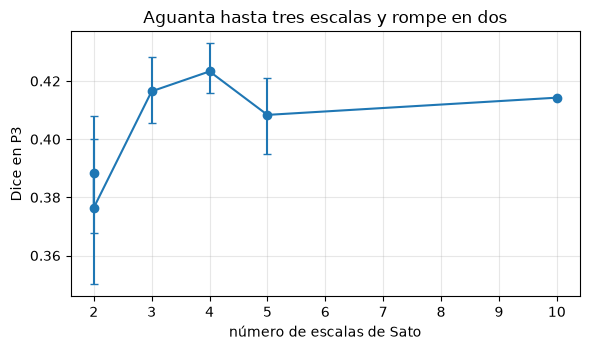

In [3]:
# ¿Gana el filtro por el a priori de cresta o por barrer el rango entero de escalas?
print(sigma.to_string(index=False, float_format=lambda v: f"{v:7.4f}"))

figura, ejes = plt.subplots(figsize=(6, 3.6))
ejes.errorbar(sigma["n_escalas"], sigma["dice"],
              yerr=[sigma["dice"] - sigma["dice"] + (sigma["menos_paso_1"] - sigma["ic_bajo"]),
                    sigma["ic_alto"] - sigma["menos_paso_1"]],
              fmt="o-", capsize=3)
ejes.set_xlabel("número de escalas de Sato")
ejes.set_ylabel("Dice en P3")
ejes.set_title("Aguanta hasta tres escalas y rompe en dos")
ejes.grid(alpha=0.3)
figura.tight_layout()
figuras.guardar(figura, "figura_f9_sigma.png")

In [4]:
# A protocolo fijo y pareado contra la fila M1 de la rejilla: positivo = gana el clásico.
gana = contra_sam[contra_sam["ic_bajo"] > 0]
print(f"El clásico gana con el intervalo entero por encima del cero en {len(gana)} de {len(contra_sam)} comparaciones")
print(gana.to_string(index=False, float_format=lambda v: f"{v:7.4f}"))

El clásico gana con el intervalo entero por encima del cero en 2 de 48 comparaciones
                  comparacion  diferencia  ic_bajo  ic_alto  unidades_ganadas  de
  sato menos sam21 en M1 x P3      0.1773   0.0850   0.2681                12  17
sato menos tinysam en M1 x P3      0.1713   0.0843   0.2624                14  17


Fraccion que supera cada umbral, por unidad
                   linea  n  t=0.1  t=0.2  t=0.3  t=0.4  t=0.5
microsam_lm M4 x P4 x S1 17  0.941  0.941  0.882  0.824  0.588
      sam21 M4 x P4 x S0 17  1.000  0.941  0.824  0.706  0.471
   sammed2d M1 x P2 x S0 17  0.941  0.824  0.588  0.412  0.000
    tinysam M4 x P4 x S1 17  1.000  0.941  0.941  0.706  0.471
          sato x P3 x S1 17  0.941  0.941  0.824  0.471  0.353

Fraccion que supera cada umbral, por frame
                   linea   n  t=0.1  t=0.2  t=0.3  t=0.4  t=0.5
microsam_lm M4 x P4 x S1 295  0.919  0.888  0.841  0.722  0.607
      sam21 M4 x P4 x S0 295  0.908  0.851  0.790  0.695  0.529
   sammed2d M1 x P2 x S0 295  0.929  0.807  0.559  0.319  0.142
    tinysam M4 x P4 x S1 295  0.946  0.902  0.790  0.651  0.502
          sato x P3 x S1 295  0.854  0.756  0.702  0.583  0.420

En t = 0.1, unidad contra frame:
curva                     frame  unidad  discrepancia
linea                                                
sam21 M4

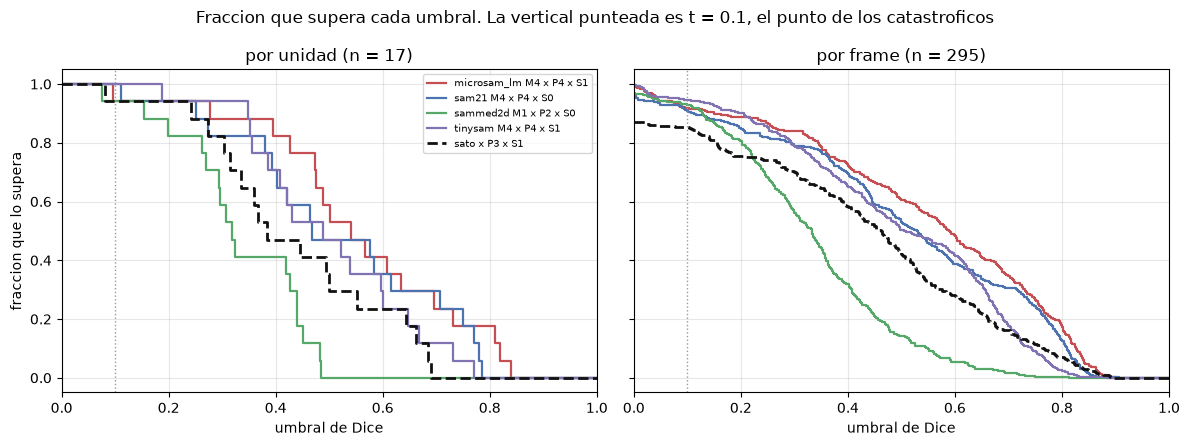

In [5]:
# Las dos curvas del apartado 6.5, que hasta ahora se calculaban y no se dibujaban.
# Cinco lineas: los cuatro de la rejilla en su mejor celda y el mejor clasico, que
# es la comparacion que sostiene el 5.4. Las celdas salen de `surco.resultados` y
# no escritas a mano, por el mismo motivo que el overlay de la celda siguiente.
#
# **Sin linea del techo humano**, y no por descuido: estas curvas son Dice contra
# el GT, y el techo es acuerdo entre dos personas que no lo vieron. Superponerlos
# seria la lectura que el apartado 7 retiro.
figuras.curvas_de_umbral("figura_a6_umbrales.png")

# La figura en numeros, que es de donde sale la lectura del 5.4. Va aparte y no a
# ojo: describir el cruce mirando el dibujo ya salio mal una vez.
fracciones = figuras.fracciones_en_umbrales()
for cual in ("unidad", "frame"):
    print(f"Fraccion que supera cada umbral, por {cual}")
    print(fracciones[fracciones["curva"] == cual].drop(columns="curva")
          .to_string(index=False, float_format=lambda v: f"{v:6.3f}"))
    print()

# La distancia entre las dos curvas en el punto de los catastroficos dice si los
# fallos son lesiones enteras o frames sueltos dentro de lesiones que salen.
anchas = fracciones.pivot(index="linea", columns="curva", values="t=0.1")
anchas["discrepancia"] = anchas["unidad"] - anchas["frame"]
print("En t = 0.1, unidad contra frame:")
print(anchas.sort_values("discrepancia", ascending=False)
      .to_string(float_format=lambda v: f"{v:6.3f}"))

In [6]:
# Overlays: el mejor clásico, sea cual sea, sobre las 34 parejas de la muestra
# estratificada del apartado 7. Las mismas unidades y frames que la figura de F10.
# El método, el protocolo y la variante salen de surco.resultados, no escritos a
# mano: escritos a mano, esta figura dibujaba la variante de una sola máscara
# cuando la mejor es la que lleva selector.
celda = figuras.mejor_clasico()
etiqueta = f"{celda['metodo']} × {celda['protocolo']} × {celda['variante']}"
pares = figuras.pares_de_figura()
figura = figuras.rejilla_de_overlays(
    pares, figuras.mascara_del_mejor_clasico,
    f"{etiqueta} · relleno = predicción, contorno = GT",
    f"overlay_{celda['metodo']}_{celda['protocolo']}_{celda['variante']}.png".lower().replace(" ", "_"),
)